Files in directory: ['000010484-AbsorptionImageExpFrag.h5', '000010482-AbsorptionImageExpFrag.h5', '000010483-AbsorptionImageExpFrag.h5', '000010481-AbsorptionImageExpFrag.h5', '000010485-AbsorptionImageExpFrag.h5', '000010486-AbsorptionImageExpFrag.h5']
File 1: ../results/2025-09-10/20/000010481-AbsorptionImageExpFrag.h5
File 2: ../results/2025-09-10/20/000010482-AbsorptionImageExpFrag.h5
File 3: ../results/2025-09-10/20/000010483-AbsorptionImageExpFrag.h5
File 4: ../results/2025-09-10/20/000010484-AbsorptionImageExpFrag.h5
File 5: ../results/2025-09-10/20/000010485-AbsorptionImageExpFrag.h5
File 6: ../results/2025-09-10/20/000010486-AbsorptionImageExpFrag.h5


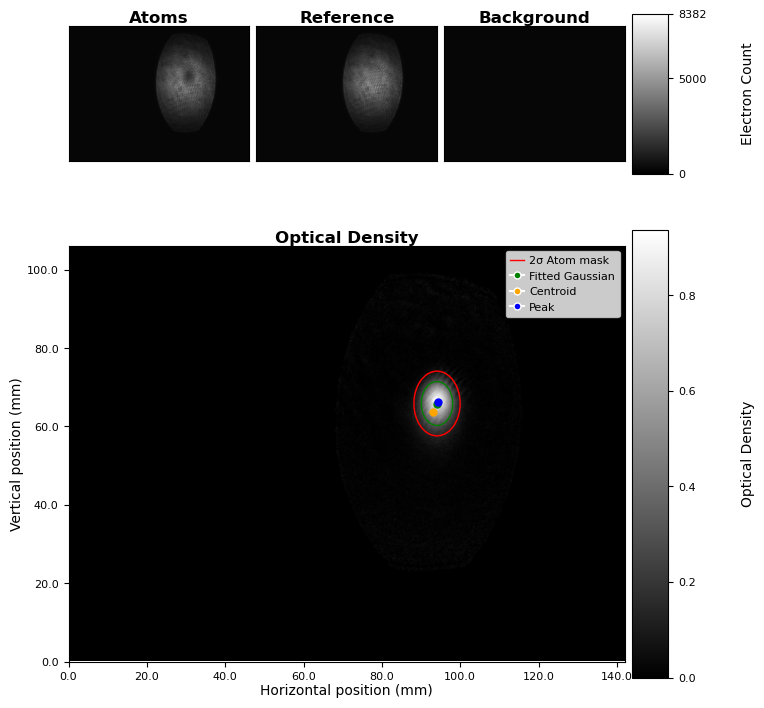

Number of files in the directory: 6
Keys in the datasets: ['Images.All.0', 'Images.All.1', 'Images.All.2', 'Images.Latest_image', 'Images.absorption.BG', 'Images.absorption.REF', 'Images.absorption.TOF', 'Images.absorption.expansion_time', 'Images.absorption.timestamp', 'ndscan.rid_10481.analysis_results', 'ndscan.rid_10481.annotations', 'ndscan.rid_10481.axes', 'ndscan.rid_10481.channels', 'ndscan.rid_10481.completed', 'ndscan.rid_10481.fragment_fqn', 'ndscan.rid_10481.ndscan_schema_revision', 'ndscan.rid_10481.online_analyses', 'ndscan.rid_10481.points.axis_0', 'ndscan.rid_10481.points.channel_atom_number', 'ndscan.rid_10481.points.channel_info', 'ndscan.rid_10481.seed', 'ndscan.rid_10481.source_id']


In [13]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys

sys.path.append(
    "/home/ae19663/artiq"
)  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage  # noqa: E402


# it will take folder(scan path) path as input and return sorted list of h5 files DIRECTORY
# the files are sorted based on the numeric part of their names, which is before the first hyphen '-'.
# For example, if the files are named like "000001234-AbsorptionImageExpFrag.h5",
# the sorting will be based on the numeric part "000001234".


folder_directory = (
    "../results/2025-09-10/20/"  # Example directory path, adjust as needed
)
file_names = os.listdir(folder_directory)

# this will print the file names in the directory
print(f"Files in directory: {file_names}")


# Enter the name of the file you want to analyze, this file consisit of many runs of of particular scan parameter if you have multiple runs
particular_directory = (
    folder_directory + "000010486-AbsorptionImageExpFrag.h5"
)  # Example file path, adjust as needed


def sorted_files(directory):
    """
    Sort files in the given directory based on the numeric part of their names.
    """
    files = os.listdir(directory)
    file_num = []
    file_name = []

    for i in files:
        # Split the file name into two parts and sort by the numeric part
        file_num.append(i.split("-")[0])
        file_name.append(i.split("-")[1])

    # Sort the files based on the numeric part
    file_num, file_name = zip(*sorted(zip(file_num, file_name)))

    # Recombine the file number and file name into a single list
    sorted_files_list = [f"{num}-{name}" for num, name in zip(file_num, file_name)]

    # Directory list for the files using the sorted file names
    files_directory = [
        os.path.join(directory, f) for f in sorted_files_list if f.endswith(".h5")
    ]

    # Example usage:
    # directory = "../results/2025-07-08/21/"
    # files_directory = sorted_files(directory)

    return files_directory


def get_override_args(file_directory, hide_defaults=True):
    vals = {}

    f1 = h5py.File(file_directory, "r")
    args = pyon.decode(f1["expid"][()])["arguments"]
    for k, v in args.items():
        if k == "ndscan_params":
            params = pyon.decode(args["ndscan_params"])
            overrides = params["overrides"]
            for k, v in overrides.items():
                spec = params["schemata"][k]["spec"]
                val = v[0]["value"]
                default = type(val)(params["schemata"][k]["default"])
                if hide_defaults and val == default:
                    continue
                vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
        else:
            vals[k] = [v, ""]
    return vals


vals = get_override_args(particular_directory, hide_defaults=False)


def args_names_and_vals(vals):
    # Print arguments names and their values
    args_names = []
    args_vals = []
    for k, (v, unit) in vals.items():
        # print(f"{k} = {v} {unit}")
        args_names.append(k)
        args_vals.append(v)
    return args_names, args_vals


files_directory = sorted_files(folder_directory)
# print(files_directory)

matching_args = []
for i in range(len(files_directory)):
    print(f"File {i + 1}: {files_directory[i]}")
    vals1 = get_override_args(files_directory[i])
    args_name1, args_val1 = args_names_and_vals(vals)
    for j in range(len(files_directory)):
        vals2 = get_override_args(files_directory[j])
        args_name2, args_val2 = args_names_and_vals(vals2)
        if args_name1 == args_name2:
            # print(f"Matching arguments found for {files_directory[i]} and {files_directory[j]}")
            matching_args.append((files_directory[i], files_directory[j]))
        else:
            # print(f"No matching arguments for {files_directory[i]} and {files_directory[j]}")
            pass


# plot the absorption image of the particular run in the scan, it is still a work in progress not working properly
def plot_absorption_image(file_directory, run_number):
    f1 = h5py.File(file_directory, "r")
    if run_number == 0:
        a = 0
    else:
        a = run_number * 3
    image_0 = "Images.All" + "." + str(a)
    image_1 = "Images.All" + "." + str(a + 1)
    image_2 = "Images.All" + "." + str(a + 2)

    absimg = AbsImage(
        data=f1["datasets"][image_0][()],
        ref=f1["datasets"][image_1][()],
        bg=f1["datasets"][image_2][()],
        magnification=0.25,  # Set default magnification
    )
    absimg.plot()
    plt.show()


scan_number = 5  # Example scan number, adjust as needed

plot_absorption_image(particular_directory, scan_number)
# Extracting the values and the units from the files
f1 = h5py.File(files_directory[0], "r")
a = f1["datasets"]

# calculate how many files are there in the directory
num_files = len(files_directory)
print(f"Number of files in the directory: {num_files}")


# extract all files images for scan parameter ranging from 0 to num_files fro 0 to 21
scan_param = [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
]

# Extracting the values and the units from the files


f1 = h5py.File(files_directory[0], "r")
a = f1["datasets"]
print(f"Keys in the datasets: {list(a.keys())}")

In [14]:
# example of the data structure in the file
import re
import pandas as pd


all = [
    "ndscan.rid_6597.analysis_results",
    "ndscan.rid_6597.annotations",
    "ndscan.rid_6597.axes",
    "ndscan.rid_6597.channels",
    "ndscan.rid_6597.completed",
    "ndscan.rid_6597.fragment_fqn",
    "ndscan.rid_6597.ndscan_schema_revision",
    "ndscan.rid_6597.online_analyses",
    "ndscan.rid_6597.points.axis_0",
    "ndscan.rid_6597.points.channel_atom_number",
    "ndscan.rid_6597.points.channel_info",
    "ndscan.rid_6597.seed",
    "ndscan.rid_6597.source_id",
]

axis1 = True  # Set to True if axis_1 exists, otherwise False

# enter the file number you want to analyze
file_number = 5  # Example file number, adjust as needed

if file_number < 0 or file_number >= len(files_directory):
    raise ValueError(
        f"File number {file_number} is out of range. Please choose a number between 0 and {len(files_directory) - 1}."
    )


# Extracting the values and the units from the files
f1 = h5py.File(files_directory[file_number], "r")
# extract file name and run number from the file path

file_name = os.path.basename(files_directory[file_number])
run_number = int(file_name.split("-")[0])
c = "ndscan.rid_" + str(run_number) + ".points.channel_info"
d = "ndscan.rid_" + str(run_number) + ".points.axis_0"

#try to find axis1 and assign it a variable like axis0, if not found ignore it
if axis1:
    try:
        e = "ndscan.rid_" + str(run_number) + ".points.axis_1"
        coil_current = f1["datasets"][e][()]
        print("axis1 found")
        print(coil_current)
    except KeyError:
        axis1 = False
        print("axis_1 not found, proceeding without it.")
        e = None


a = f1["datasets"][c][()]

peakx = []
peaky = []
centroidx = []
centroidy = []
wavelength = []
atom_number = []
A = []
sx = []
sy = []
x0 = []
y0 = []


for i in range(a.shape[0]):
    # decode if bytes, otherwise use as is
    if isinstance(a[i], bytes):
        decoded = a[i].decode("utf-8")
        lines = decoded.split("\n")

    else:
        lines = a[i]

    for line in lines:
        b = line.strip(",").split(":")
        key = b[0].strip().strip('"')
        if key == "wavelength":
            wavelength.append(float(b[1]))
        elif key == "atom_number":
            atom_number.append(float(b[1]))
        elif key == "peak_pixel":  # Assuming this is a key for peak pixels
            # extract numbers from tuple string
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                peakx.append(float(nums[0]))
                peaky.append(float(nums[1]))
                # If you want the third value, use float(nums[2])
            # else skip or handle error
        elif key == "centroid_pixel":  # Assuming this is a key for centroid pixels
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                centroidx.append(float(nums[0]))
                centroidy.append(float(nums[1]))
                # If you want the third value, use float(nums[2])
        elif key == "best_values_pixel":  # Assuming this is a key for some values
            # Extract dictionary from line
            match = re.search(r"\{(.+?)\}", line)
            if match:
                dict_str = match.group(1)
                items = dict_str.split(",")
                for item in items:
                    item = item.strip()
                    if ":" in item:
                        key_part, value_part = item.split(":", 1)
                        key_item = key_part.strip().strip("'")
                        value_str = value_part.strip()
                        # Convert to float or int
                        if "." in value_str or "e" in value_str:
                            value = float(value_str)
                        else:
                            value = int(value_str)
                        # Append to the correct list
                        if key_item == "A":
                            A.append(value)
                        elif key_item == "x0":
                            x0.append(value)
                        elif key_item == "y0":
                            y0.append(value)
                        elif key_item == "sx":
                            sx.append(value)
                        elif key_item == "sy":
                            sy.append(value)
                        elif key_item == "theta":
                            if "theta" not in locals():
                                theta = []
                            theta.append(value)
                        elif key_item == "z0":
                            if "z0" not in locals():
                                z0 = []
                            z0.append(value)


# extract scan parameters from the file
scan_params = f1["datasets"][d][()]
#add more decimal places to scan params

print(scan_params)

# list contents in datasets
datasets = list(f1["datasets"].keys())
print("Datasets in the file:", datasets)


# print the extracted values
print("Wavelength:", wavelength)
print("Atom Number:", atom_number)
print("Peak X:", peakx)
print("Peak Y:", peaky)
print("Centroid X:", centroidx)
print("Centroid Y:", centroidy)
print("A:", A)
print("Sx:", sx)
print("Sy:", sy)
print("X0:", x0)
print("Y0:", y0)

# store everything in the csv file also scan parameters
data = {
    "wavelength": wavelength,
    "atom_number": atom_number,
    "peakx": peakx,
    "peaky": peaky,
    "centroidx": centroidx,
    "centroidy": centroidy,
    "A": A,
    "sx": sx,
    "sy": sy,
    "x0": x0,
    "y0": y0,
    "scan_params": scan_params,
}

# save file in this directory with file name as the run number
#output_directory = "./"
#output_file = os.path.join(output_directory, f"extracted_data_run_{run_number}.csv")
#df = pd.DataFrame(data)
#df.to_csv(output_file, index=False)
#print(f"Data saved to {output_file}")



axis_1 not found, proceeding without it.
[0.015 0.007 0.003 0.013 0.001 0.011 0.017 0.005 0.009]
Datasets in the file: ['Images.All.0', 'Images.All.1', 'Images.All.10', 'Images.All.11', 'Images.All.12', 'Images.All.13', 'Images.All.14', 'Images.All.15', 'Images.All.16', 'Images.All.17', 'Images.All.18', 'Images.All.19', 'Images.All.2', 'Images.All.20', 'Images.All.21', 'Images.All.22', 'Images.All.23', 'Images.All.24', 'Images.All.25', 'Images.All.26', 'Images.All.3', 'Images.All.4', 'Images.All.5', 'Images.All.6', 'Images.All.7', 'Images.All.8', 'Images.All.9', 'Images.Latest_image', 'Images.absorption.BG', 'Images.absorption.REF', 'Images.absorption.TOF', 'Images.absorption.expansion_time', 'Images.absorption.timestamp', 'ndscan.rid_10486.analysis_results', 'ndscan.rid_10486.annotations', 'ndscan.rid_10486.axes', 'ndscan.rid_10486.channels', 'ndscan.rid_10486.completed', 'ndscan.rid_10486.fragment_fqn', 'ndscan.rid_10486.ndscan_schema_revision', 'ndscan.rid_10486.online_analyses', 'n

after adding exposure time [0.01503 0.00703 0.00303 0.01303 0.00103 0.01103 0.01703 0.00503 0.00903]


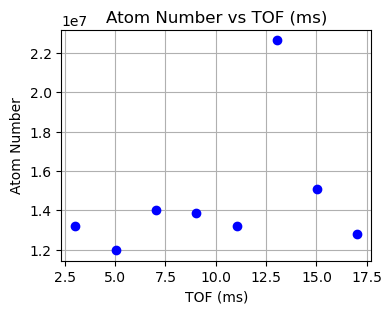

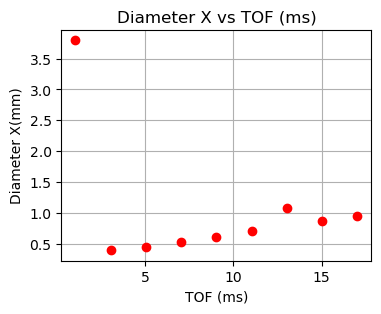

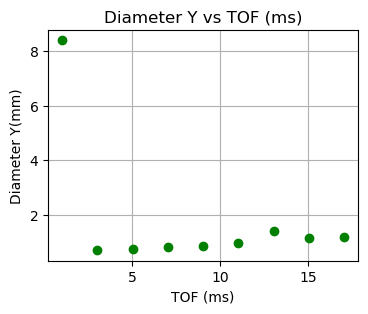

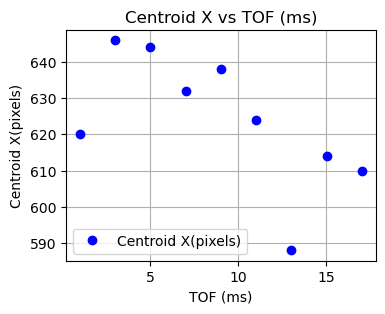

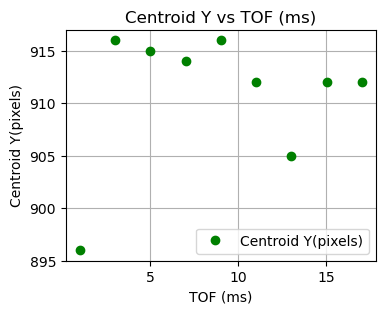

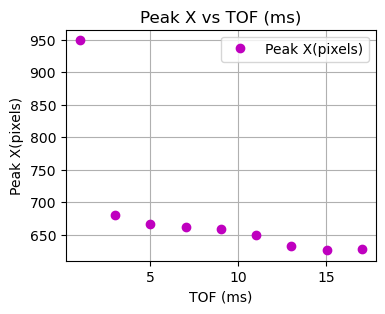

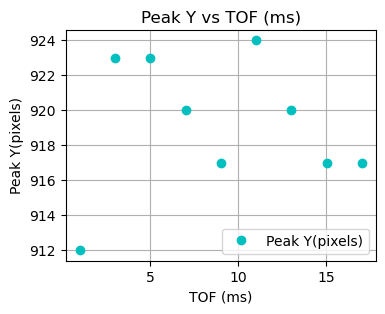

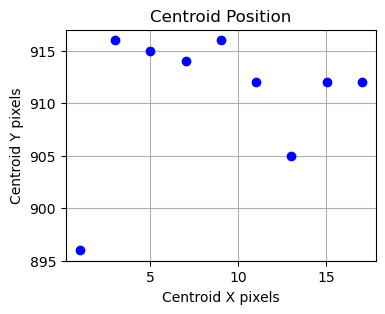

In [15]:
# exposure time
exposure_time = 0.03e-3

scaling_factor = 25.52 * 1e-6

# add the exposure time to tof
#scan_params = scan_params + exposure_time

sx = np.array(sx) * scaling_factor  # Convert to mm
sy = np.array(sy) * scaling_factor  # Convert to mm


scan_params = f1["datasets"][d][()]
scan_params=np.array(scan_params)
scan_params = scan_params + exposure_time

if e is not None:
    axis1_params = f1["datasets"][e][()]
    #print("coil_current:", axis1_params)


# plot the atom number vs the scan parameter(TOF)
def plot_atom_number_vs_scan_param(atom_number, scan_params, d):
    """
    Plot atom number vs scan parameter from the given HDF5 file.
    """
    
    print("after adding exposure time", np.round(scan_params, 7))
    plt.figure(figsize=(4, 3))
    plt.plot(scan_params * 1e3, atom_number, marker="o", linestyle="none", color="b")
    plt.xlabel("TOF (ms)")
    plt.ylabel("Atom Number")
    plt.title("Atom Number vs " +"TOF (ms)")
    plt.grid()
    plt.show()


plot_atom_number_vs_scan_param(atom_number, scan_params, d)


# plot the diameterx vs the scan parameter(TOF)
def plot_diameterx_vs_scan_param(diameterx, scan_params, d):
    """
    Plot diameterx vs scan parameter from the given HDF5 file.
    """
    #scan_params = f1["datasets"][d][()]

    #print(scan_params)
    #print(diameterx)
    plt.figure(figsize=(4, 3))
    plt.plot(scan_params * 1e3, diameterx*1e3, marker="o", linestyle="none", color="r")
    plt.xlabel("TOF (ms)")
    plt.ylabel("Diameter X(mm)")
    plt.title("Diameter X vs " + "TOF (ms)")
    plt.grid()
    plt.show()


plot_diameterx_vs_scan_param(sx, scan_params, d)


def plot_diametery_vs_scan_param(diametery, scan_params, d):
    """
    Plot diametery vs scan parameter from the given HDF5 file.
    """

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params * 1e3, diametery*1e3, marker="o", linestyle="none", color="g")
    plt.xlabel("TOF (ms)")
    plt.ylabel("Diameter Y(mm)")
    plt.title("Diameter Y vs " + "TOF (ms)")
    plt.grid()
    plt.show()


plot_diametery_vs_scan_param(sy, scan_params, d)


def plot_centroid_vs_scan_param(centroidx, scan_params, d):
    """
    Plot centroid vs scan parameter from the given HDF5 file.
    """

    plt.figure(figsize=(4, 3))
    plt.plot(
        scan_params * 1e3,
        centroidx,
        marker="o",
        linestyle="none",
        color="b",
        label="Centroid X(pixels)",
    )
    plt.xlabel("TOF (ms)")
    plt.ylabel("Centroid X(pixels)")
    plt.title("Centroid X vs " + "TOF (ms)")
    plt.legend()
    plt.grid()
    plt.show()


plot_centroid_vs_scan_param(centroidx, scan_params, d)


def plot_centroidy_vs_scan_param(centroidy, scan_params, d):
    """
    Plot centroidy vs scan parameter from the given HDF5 file.
    """
    #scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(
        scan_params * 1e3,
        centroidy,
        marker="o",
        linestyle="none",
        color="g",
        label="Centroid Y(pixels)",
    )
    plt.xlabel("TOF (ms)")
    plt.ylabel("Centroid Y(pixels)")
    plt.title("Centroid Y vs " + "TOF (ms)")
    plt.legend()
    plt.grid()
    plt.show()


plot_centroidy_vs_scan_param(centroidy, scan_params, d)


def plot_peak_vs_scan_param(peakx, scan_params, d):
    """
    Plot peak vs scan parameter from the given HDF5 file.
    """
    #scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(
        scan_params * 1e3,
        peakx,
        marker="o",
        linestyle="none",
        color="m",
        label="Peak X(pixels)",
    )
    plt.xlabel("TOF (ms)")
    plt.ylabel("Peak X(pixels)")
    plt.title("Peak X vs " + "TOF (ms)")
    plt.legend()
    plt.grid()
    plt.show()


plot_peak_vs_scan_param(peakx, scan_params, d)


def plot_peaky_vs_scan_param(peaky, scan_params, d):
    """
    Plot peaky vs scan parameter from the given HDF5 file.
    """
    #scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(
        scan_params * 1e3,
        peaky,
        marker="o",
        linestyle="none",
        color="c",
        label="Peak Y(pixels)",
    )
    plt.xlabel("TOF (ms)")
    plt.ylabel("Peak Y(pixels)")
    plt.title("Peak Y vs " + "TOF (ms)")
    plt.legend()
    plt.grid()
    plt.show()


plot_peaky_vs_scan_param(peaky, scan_params, d)


def plot_centroid_position(centroidx, centroidy, d):
    """
    Plot centroid position from the given HDF5 file.
    """
    plt.figure(figsize=(4, 3))
    plt.scatter(centroidx, centroidy, marker="o", color="b")
    plt.xlabel("Centroid X (pixels)")
    plt.ylabel("Centroid Y (pixels)")
    plt.title("Centroid Position")
    plt.grid()
    plt.show()


# make a plot function for general plotting with units specified
def plot_general(
    x,
    y,
    xlabel,
    ylabel,
    title,
    xunit="",
    yunit="",
    color="b",
    marker="o",
    linestyle="none",
):
    """
    General plotting function.
    """
    plt.figure(figsize=(4, 3))
    plt.plot(x, y, marker=marker, linestyle=linestyle, color=color)
    plt.xlabel(xlabel + " " + xunit)
    plt.ylabel(ylabel + " " + yunit)
    plt.title(title)
    plt.grid()
    plt.show()


# plot centroid position
plot_general(
    scan_params * 1e3,
    centroidy,
    "Centroid X",
    "Centroid Y",
    "Centroid Position",
    xunit="pixels",
    yunit="pixels",
    color="b",
)

TOF data: [0.01503 0.00703 0.00303 0.01303 0.00103 0.01103 0.01703 0.00503 0.00903]
Diameter data: [0.00114365 0.00083497 0.00071168 0.00141736 0.00838794 0.00098783
 0.0011949  0.00075886 0.00087662]
Sorted TOF data: [0.00103 0.00303 0.00503 0.00703 0.00903 0.01103 0.01303 0.01503 0.01703]
Sorted Diameter data: [0.00838794 0.00071168 0.00075886 0.00083497 0.00087662 0.00098783
 0.00141736 0.00114365 0.0011949 ]
[7.05241682e-04 4.50176545e-05]


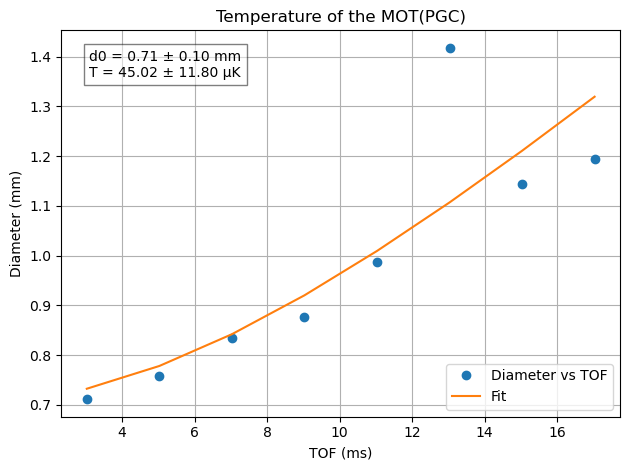

d0 = 0.7052 ± 0.0962 μm
T = 45.0177 ± 11.7974 μK
Final temperature: 45.0177 ± 0.0000 µK


In [16]:
# curve fitting to find the diameter as a function of time of flight (TOF)
import numpy as np

t_data = scan_params # TOF data
d_data = np.array(sy)  # Diameter data, using sy as an example


print("TOF data:", t_data)
print("Diameter data:", d_data)

# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)

# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


ind = get_index_of_value(t_data_sorted[0], t_data)

# diameter data sorted
d_data_sorted = d_data[np.argsort(t_data)]
print("Sorted Diameter data:", d_data_sorted)

# Boltzmann constant
kB = 1.380649e-23  # J/K
m = 1.45e-25  # kg



# http://ultracold.physi.uni-heidelberg.de/files/diplomarbeit-friedhelm.pdf

# Model: sqrt(d0^2 + (kB * T/m) * t^2)



def model(t, d0, T):
    return np.sqrt(d0**2 + (kB * T * t**2) / m)

#remove first data point from t_data_sorted and d_data_sorted
t_data_sorted = t_data_sorted[1:]
d_data_sorted = d_data_sorted[1:]

# Fit your existing data
bounds = ([0, 0], [np.inf, np.inf])  # d0 and T must be positive
p0 = [2e-3, 100e-6]  # Initial guess
popt, pcov = curve_fit(model, t_data_sorted, d_data_sorted, p0=p0, bounds=bounds)
d0_fit, T_fit = popt
d0_err, T_err = np.sqrt(np.diag(pcov))

print(popt)

# Plot
plt.plot(t_data_sorted * 1e3, d_data_sorted * 1e3, "o", label="data")
plt.plot(t_data_sorted * 1e3, model(t_data_sorted, *popt) * 1e3, label="fit")
plt.xlabel("TOF (ms)")
plt.ylabel("Diameter (mm)")
plt.legend(["Diameter vs TOF", "Fit"])
plt.title("Temperature of the MOT(PGC)")

# add fit results to the plot with box with proper formatting
fit_text = f"d0 = {d0_fit * 1e3:.2f} ± {d0_err * 1e3:.2f} mm\nT = {T_fit * 1e6:.2f} ± {T_err * 1e6:.2f} μK"
plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print results
print(f"d0 = {d0_fit * 1e3:.4f} ± {d0_err * 1e3:.4f} μm")
print(f"T = {T_fit * 1e6:.4f} ± {T_err * 1e6:.4f} μK")


# Known values
s = 28.19  # Pixel size in µm/pixel
delta_s = 10.59  # Uncertainty in pixel size

# Calculate pixel-size-based uncertainty
delta_T_pixel = T_fit * 2 * (delta_s / s)

# Combine both uncertainties
delta_T_total = np.sqrt(T_err**2 + delta_T_pixel**2)

print(f"Final temperature: {T_fit * 1e6:.4f} ± {delta_T_total:.4f} µK")


Pixel data: [626. 661. 680. 632. 949. 650. 628. 666. 658.]
TOF data: [0.01503 0.00703 0.00303 0.01303 0.00103 0.01103 0.01703 0.00503 0.00903]
Sorted TOF data: [0.00103 0.00303 0.00503 0.00703 0.00903 0.01103 0.01303 0.01503 0.01703]
Sorted Pixel data: [949. 680. 666. 661. 658. 650. 632. 626. 628.]
y0 = 10.5399402 ± 3.9712796 pixels
s = 26.3120730 ± 3.6508318 μm


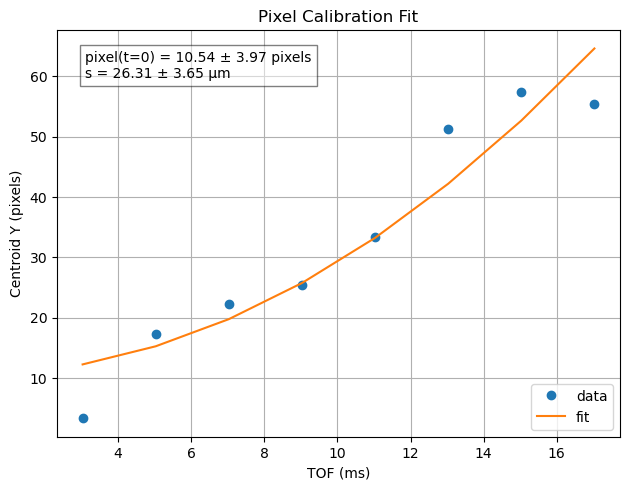

In [17]:
# pixel calibration fit
g = 9.81  # m/s^2, gravitational acceleration

pixel_number_vertical_data = np.array(peakx)  # Pixel data, using peakx as an example
print("Pixel data:", pixel_number_vertical_data)

print("TOF data:", t_data)


# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)




# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


# pixel data sorted
pixel_data_sorted = pixel_number_vertical_data[np.argsort(t_data)]
print("Sorted Pixel data:", pixel_data_sorted)

pixel_data_sorted = -(pixel_data_sorted - np.mean(pixel_data_sorted))

#remove frist data point from t_data_sorted and pixel_data_sorted
t_data_sorted = t_data_sorted[1:]
pixel_data_sorted = pixel_data_sorted[1:]


def model_pixel_calibration(t, y0, s):
    return y0 + (1 / 2) * t**2 * g / s


# Initial GUESS
y0_initial = 0.0
s_initial = 40e-6



# Fit your existing data
popt_pixel, pcov_pixel = curve_fit(
    model_pixel_calibration,
    t_data_sorted,
    pixel_data_sorted,
    p0=[y0_initial, s_initial],
)
y0_fit = popt_pixel[0]
y0_err = np.sqrt(np.diag(pcov_pixel))[0]
s_fit = popt_pixel[1]
s_err = np.sqrt(np.diag(pcov_pixel))[1]

# Print results
print(f"y0 = {y0_fit:.7f} ± {y0_err:.7f} pixels")
print(f"s = {s_fit * 1e6:.7f} ± {s_err * 1e6:.7f} μm")


# Plot pixel calibration
plt.plot(t_data_sorted * 1e3, pixel_data_sorted, "o", label="data")
plt.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    label="fit",
)
plt.xlabel("TOF (ms)")
plt.ylabel("Centroid Y (pixels)")
plt.legend()
plt.grid(True)

fit_text = (
    f"pixel(t=0) = {y0_fit:.2f} ± {y0_err:.2f} pixels\ns = {s_fit * 1e6:.2f} ±"
    f" {s_err * 1e6:.2f} μm"
)
plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
)
plt.tight_layout()
plt.title("Pixel Calibration Fit")
plt.show()

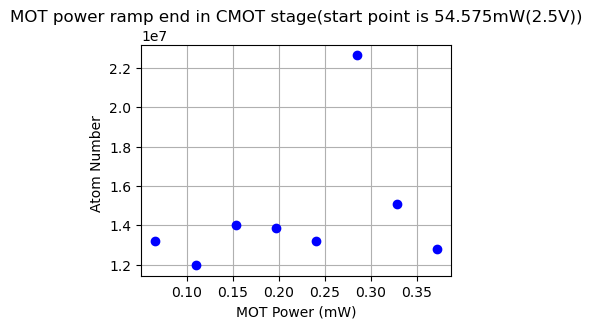

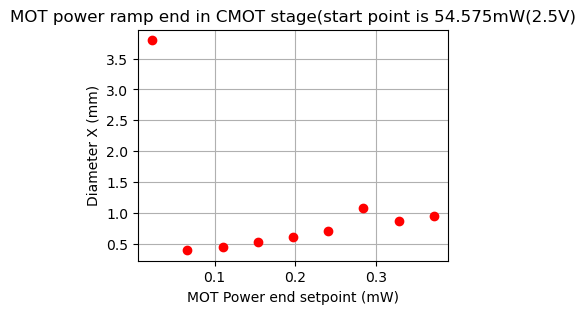

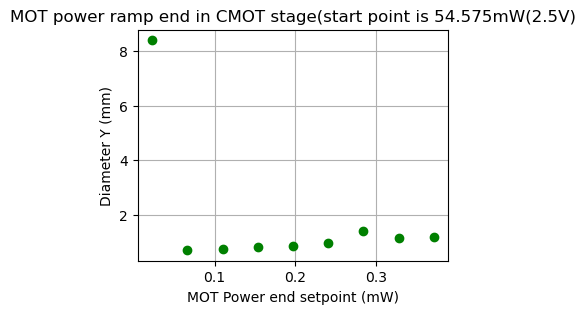

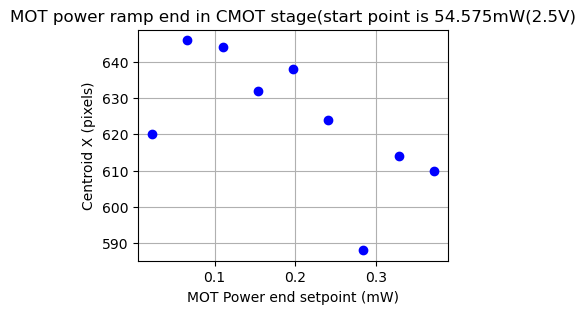

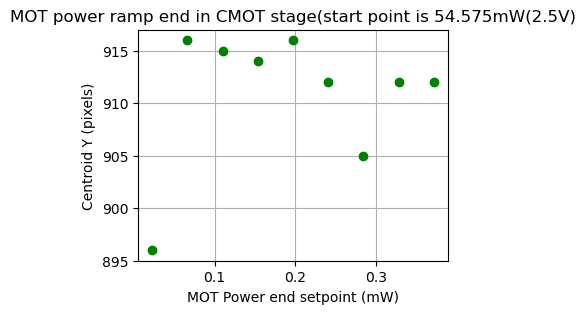

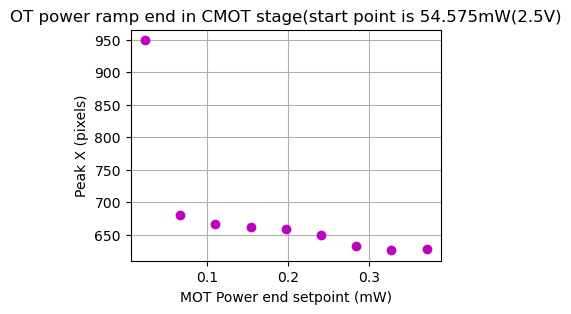

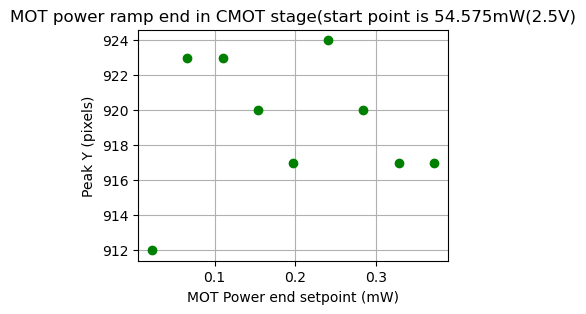

In [18]:
scan_params = scan_params*21.83

# plot atom number vs coil current
plot_general(
    scan_params,
    atom_number,
    "MOT Power",
    "Atom Number",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V))",
    xunit="(mW)",
    yunit="",
    color="b",
)

# plot all other parameters vs coil current  
plot_general(
    scan_params,
    sx * 1e3,
    "MOT Power end setpoint",
    "Diameter X",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(mm)",
    color="r",
)
plot_general(
    scan_params,
    sy * 1e3,
    "MOT Power end setpoint",
    "Diameter Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(mm)",
    color="g",
)
plot_general(
    scan_params,
    centroidx,
    "MOT Power end setpoint",
    "Centroid X",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="b",
)
plot_general(
    scan_params,
    centroidy,
    "MOT Power end setpoint",
    "Centroid Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="g",
)
plot_general(
    scan_params,
    peakx,
    "MOT Power end setpoint",
    "Peak X",
    "OT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="m",
)
plot_general(
    scan_params,
    peaky,
    "MOT Power end setpoint",
    "Peak Y",
    "MOT power ramp end in CMOT stage(start point is 54.575mW(2.5V)",
    xunit="(mW)",
    yunit="(pixels)",
    color="g",
)




In [24]:
sx=0.036e-2
sy=0.068e-2
atom_number=6e7
#in cm^-3
volume = (4 / 3) * np.pi * (sx / 2) * (sy / 2) * (sx / 2)

def calculate_density(atom_number, volume):
    return atom_number / volume
density = calculate_density(atom_number, volume)
print("Density(cm^-3):", density)  

Density(cm^-3): 1.3002854827769226e+18
